# Trabajo Práctico Final Grupo 3

<h2> Introducción </h2>

<div style="text-align: justify;"> 
El Gobierno de la Ciudad Autónoma de Buenos Aires pone a disposición de los ciudadanos un catálogo
de datos públicos y abiertos que la Ciudad produce diariamente. Para el presente Trabajo Práctico
vamos a utilizar el set de datos o dataset que se encuentra en el siguiente enlace:
Link principal: https://data.buenosaires.gob.ar/dataset/ba-obras
El objetivo del TP es resolver en grupos los puntos que se piden más abajo y exponer los resultados en
clase.
</div>

## Se pide:

1) Cantidad de obras en etapa de Ejecución.
2) % de obras en etapa Finalizada.
3) Total de Monto Contratado para el año 2011
4) Total de Monto Contratado para el período 2018-2022
5) Cantidad de licitaciones por año
6) Cantidad de Obras para el Barrio Liniers
7) Total de Monto Contratado para el Barrio Boedo
8) Importe Total para obras con plazo de hasta 8 meses
9) Inversión planificada en Salud
10) Inversión total en Salud (realizada + planificada)
11) Inversión total en Educación (realizada + planificada)
12) Importe de la obra más costosa
13) Importe de la obra más costosa en Transporte
14) Importe de la obra más costosa en Obra Hidráulica e Infraestructura
15) Cantidad de Obras para el área responsable “Ministerio de Salud”

## Desarrollo

In [1]:
# Importación de libreria Pandas

import pandas as pd

# importar numpy y nombrarlo como 'np'
import numpy as np

# importar matplotlib y nombrarlo como plt
import matplotlib.pyplot as plt 

# importar locale y configurar la localización
import locale
try:
    locale.setlocale(locale.LC_ALL, 'es_ES.UTF-8')
except locale.Error:
    try:
        locale.setlocale(locale.LC_ALL, 'es_ES')
    except:
        print("Advertencia: No se pudo establecer la configuración regional 'es_ES'.")



# Almacenar en variable los Data Frames llegados desde el Excel

df = pd.read_csv("observatorio-de-obras-urbanas.csv", 
                encoding="latin-1", 
                sep=";",
                engine="python")

### Funciones auxiliares para restablecer formato monetario y convertir la columna "monto_contrato" a float

In [2]:
import locale

import numpy as np


# Función robusta para convertir monto_contrato a float

def limpiar_monto(valor):

    if isinstance(valor, str):

        valor = valor.replace('$', '').replace('.', '').replace(',', '.')

        try:
            return float(valor)
        
        except ValueError:
            return np.nan
        
    return valor


def formato_monetario( valorNumerico ):

  try:
    locale.setlocale(locale.LC_ALL, '')

    
  except locale.Error:

    try:
      locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')

    except locale.Error:
      pass 

  return locale.format_string("%.2f", valorNumerico, grouping=True)

## 1) Cantidad de obras en etapa de Ejecución.

In [3]:
# definir en una lista los valores a buscar (en minúsculas y sin espacios)
ETAPAS_A_BUSCAR = ['en ejecución', 'en curso', 'en obra']

# homologar la columna 'etapa' (en minúsculas y sin espacios)
columna_limpia = df['etapa'].str.lower().str.strip()

# buscar con 'isin() si un valor está dentro de la lista de posibles valores
cantidad_obras_filtradas = columna_limpia.isin(ETAPAS_A_BUSCAR).sum()

# imprimir el resultado de la suma
print(f"La cantidad total de obras en etapa de en ejecución es: {cantidad_obras_filtradas}")

La cantidad total de obras en etapa de en ejecución es: 120


## 2) % de obras en etapa Finalizada.

In [4]:
# definir en una lista los valores a buscar (en minúsculas y sin espacios)
ETAPAS_A_BUSCAR = ['finalizada', 'finalizada/desestimada', 'proyecto finalizado']

# buscar con 'isin() si un valor está dentro de la lista de posibles valores
cantidad_obras_filtradas = columna_limpia.isin(ETAPAS_A_BUSCAR).sum()

# cantidad de filas en la columna 'etapa'
CANTIDAD_OBRAS = df['etapa'].count()

#calculo de porcentaje de obras Finalizadas
porcentaje_obras_finalizadas = (cantidad_obras_filtradas / CANTIDAD_OBRAS) * 100

# imprimir el resultado de la suma
print(f"El porcentaje de obras en etapa finalizada es: {porcentaje_obras_finalizadas:.2f}%")

El porcentaje de obras en etapa finalizada es: 88.59%


## 3) Total de Monto Contratado para el año 2011.

In [5]:
# comando para asegurar que la columna 'fecha_inicio' se lea como DD/MM/YYYY
df['fecha_inicio'] = pd.to_datetime(df['fecha_inicio'], format='%d/%m/%Y', errors='coerce')

In [6]:
df['monto_contrato'] = df['monto_contrato'].apply(limpiar_monto)

# año que queremos analizar
AÑO_ANALIZADO = 2011

# filtrar por año deseado y sumar
suma_total_año = df[df['fecha_inicio'].dt.year == AÑO_ANALIZADO]['monto_contrato'].sum()

In [7]:
# formatear el resultado para que se muestre según la moneda local
resultado_formateado = locale.format_string("%.2f", suma_total_año, grouping=True)

# imprimir el dato sumado
print(f"Suma total de los contratos para el año {AÑO_ANALIZADO}: $ {resultado_formateado}")

Suma total de los contratos para el año 2011: $ 2.227.000.000,00


## 4) Total de Monto Contratado para el período 2018-2022

In [8]:
# filtrar el DataFrame para el rango de años 2018 a 2022
df_filtrado = df[
    (df['fecha_inicio'].dt.year >= 2018) & 
    (df['fecha_inicio'].dt.year <= 2022)
]

#df['monto_contrato'] = df['monto_contrato'].apply(limpiar_monto)

# sumar los montos de esos años
suma_total_2018_2022 = df_filtrado['monto_contrato'].sum()

In [9]:
# formatear el resultado para que se muestre según la moneda local
resultado_formateado = locale.format_string("%.2f", suma_total_2018_2022, grouping=True)

# mostrar el resultado
print(f"La suma total de los montos entre 2018 y 2022 es: $ {resultado_formateado}")

La suma total de los montos entre 2018 y 2022 es: $ 60.203.802.967,66


## 5) Cantidad de licitaciones por año

In [10]:
df[ 'licitacion_anio' ].value_counts()

licitacion_anio
2017             426
2016             324
2022             156
2023             129
2018             110
2021              80
2019              76
2014              75
2015              39
2020              30
2013              14
2024              11
2012               3
2007               2
512-0730-OC17      1
1900               1
2009               1
2003               1
2010               1
-                  1
2005               1
2025               1
Name: count, dtype: int64

In [11]:
# comandos para limpiar datos ilogicos
columna_a_limpiar = 'licitacion_anio'

# lista de valores a limpiar
valores_ilogicos = ['1900', '1900.0', '-', '512-0730-OC17']

# reemplzar valores por NaN
df[columna_a_limpiar] = df[columna_a_limpiar].replace(
    valores_ilogicos, np.nan
)

# .copy() agregado para evitar warning de pandas
df_limpio = df.dropna(subset=[columna_a_limpiar]).copy()

# CONVERSIÓN A INT64: Esto elimina el ".0" y establece el tipo de dato en int64
df_limpio[columna_a_limpiar] = df_limpio[columna_a_limpiar].astype('int64')

# mostrar resultados en orden descendente según  año
print(df_limpio[columna_a_limpiar].value_counts().sort_index(ascending=False))

licitacion_anio
2025      1
2024     11
2023    129
2022    156
2021     80
2020     30
2019     76
2018    110
2017    426
2016    324
2015     39
2014     75
2013     14
2012      3
2010      1
2009      1
2007      2
2005      1
2003      1
Name: count, dtype: int64


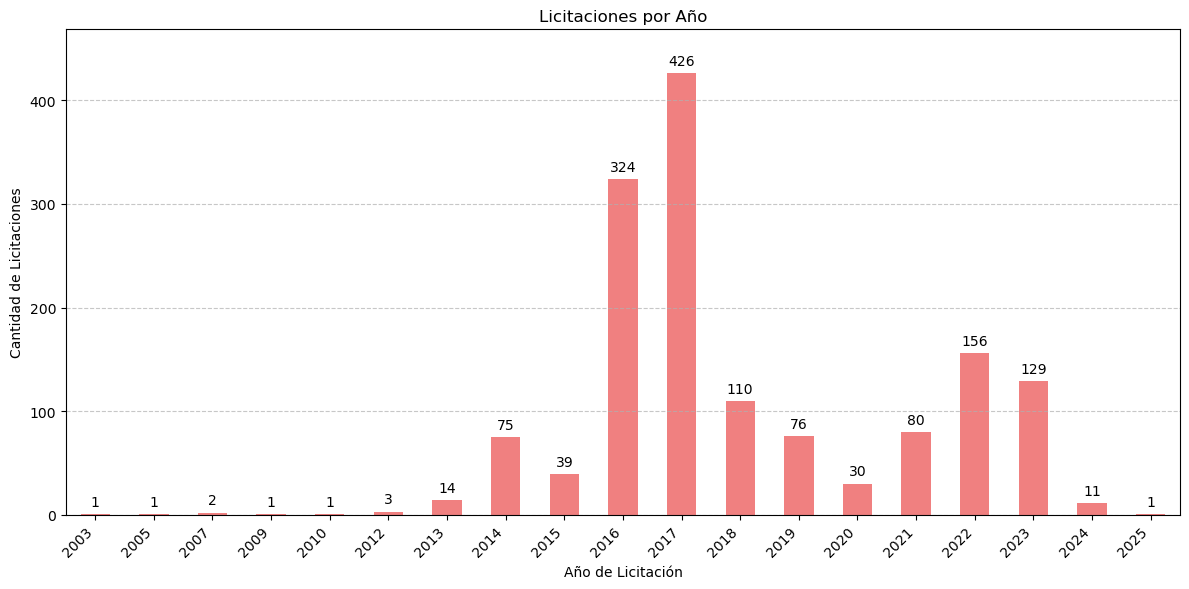

In [12]:
# graficar
# 1. Genera la serie de conteos y la ordena por el índice (el año) de mayor a menor
#    Usamos 'licitacion_anio' como el nombre de columna correcto.
conteo_ordenado_por_anio = df_limpio['licitacion_anio'].value_counts().sort_index()

# 2. Crea la figura y los ejes para el gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Genera el gráfico de barras en el eje creado (ax)
barras = conteo_ordenado_por_anio.plot(
    kind='bar',
    ax=ax,
    color='lightcoral'
)

# 4. Bucle para añadir las etiquetas de datos (el número encima de cada barra)
for bar in barras.patches:
    # 'bar.get_height()' obtiene el valor del conteo
    # 'bar.get_x() + bar.get_width() / 2' obtiene la posición central de la barra en el eje X
    # 'bar.get_height() + 5' coloca el texto 5 unidades por encima de la barra
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # Posición X (centro de la barra)
        bar.get_height() + 5,               # Posición Y (altura de la barra + pequeño desplazamiento)
        int(bar.get_height()),              # El texto a mostrar (el conteo)
        ha='center',                        # Alineación horizontal: centrado
        va='bottom',                        # Alineación vertical: en la parte inferior del texto
        fontsize=10
    )

# 5. Añade etiquetas, título y ajusta el eje Y
plt.title('Licitaciones por Año')
plt.xlabel('Año de Licitación')
plt.ylabel('Cantidad de Licitaciones')
plt.xticks(rotation=45, ha='right')
# Ajusta el límite superior del eje Y para dejar espacio para las etiquetas
ax.set_ylim(0, conteo_ordenado_por_anio.max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6) Cantidad de Obras para el Barrio Liniers

In [13]:
valores = [
    'En obra', 'En ejecución', 'Adjudicada', 'En Ejecución',
    'En Obra', 'En proyecto', 'En curso', 'Anteproyecto', 'En armado de pliegos', 'En licitación'
]

# Filtramos por etapa y barrio Liniers
cantidadObrasLiniers = int( df[ (df['etapa'].isin(valores)) & (df['barrio'] == 'Liniers')]['barrio'].count() )

print(cantidadObrasLiniers)

3


## 7) Total de Monto contratado para el Barrio Boedo

In [14]:
df['monto_contrato'] = df['monto_contrato'].apply(limpiar_monto)

totalBoedo = df.loc[df['barrio'] == 'Boedo', 'monto_contrato'].sum()

totalBoedo = formato_monetario(totalBoedo)

print("$",totalBoedo)

$ 263.989.273,84


## 8) Importe Total para obras con plazo de hasta 8 meses

In [15]:
df[ 'plazo_meses' ] = pd.to_numeric( df['plazo_meses'], errors='coerce' )

totalObras8Meses = df.loc[ df['plazo_meses'] <= 8, 'monto_contrato'].sum()

totalObras8Meses = formato_monetario(totalObras8Meses)

print("$", totalObras8Meses)

$ 30.740.362.644,62


## 9) Inversión planificada en Salud

In [16]:
valores = [
    'En obra', 'En ejecución', 'Adjudicada', 'En Ejecución',
    'En Obra', 'En proyecto', 'En curso', 'Anteproyecto'
]


# Use la función robusta definida previamente (limpiar_monto) para manejar distintos formatos y valores faltantes, asegurandose que es float

df['monto_contrato'] = df['monto_contrato'].apply(limpiar_monto)


inversionPlanificadaSalud = df[(df['etapa'].isin(valores)) & (df['tipo'] == 'Salud')]['monto_contrato'].sum()

inversionPlanificadaSalud = formato_monetario( inversionPlanificadaSalud )

print("$",inversionPlanificadaSalud )

$ 9.306.956.129,12


## 10) Inversión total en Salud ( realizada + planificada )

In [17]:
df['monto_contrato'] = df['monto_contrato'].apply( limpiar_monto )


inversionTotalSalud = df[ (df['tipo'] == 'Salud' )]['monto_contrato'].sum()

inversionTotalSalud = formato_monetario(inversionTotalSalud)

print("$",inversionTotalSalud)

$ 16.964.272.389,87


## 11) Inversión total en Educación (realizada + planificada)

In [18]:
df['monto_contrato'] = df['monto_contrato'].apply( limpiar_monto )


inversionTotalEducacion = df[ ( df['area_responsable'] == 'Ministerio de Educación') ]['monto_contrato'].sum()

inversionTotalEducacion = formato_monetario(inversionTotalEducacion)

print("$",inversionTotalEducacion)

$ 25.982.207.170,43


## 12) Importe de la obra costosa

In [19]:
df['monto_contrato'] = df['monto_contrato'].apply( limpiar_monto )


maxMonto = df['monto_contrato'].max()

maxMonto = formato_monetario( maxMonto )


print("$",maxMonto)

$ 13.866.795.333,67


## 13) Importe de la obra más costosa en Transporte

In [20]:
df['monto_contrato'] = df['monto_contrato'].apply( limpiar_monto )

montoMaxTransporte = df[df['tipo'] == 'Transporte']['monto_contrato'].max()


montoMaxTransporte = formato_monetario( montoMaxTransporte )


print( "$", montoMaxTransporte )

$ 3.183.200.000,00


In [21]:
print(df['tipo'].unique())

['Escuelas' 'Espacio Público' 'Vivienda' 'Hidráulica e Infraestructura'
 'Arquitectura' 'Transporte' 'Salud' 'Hidráulica E Infraestructura'
 'Vivienda Nueva' nan 'Hidráulica e Infraestructura/ Espacio Público'
 'Instalaciones' 'Ingenieria' 'Patio de Juegos' 'Infraestructura'
 'Hidraulica' 'Espacio Público y Vial']


## 14) Importe de la obra más costosa en Obra Hidráulica e Infraestructura

In [ ]:
valoresHyI = [

    'Hidráulica e Infraestructura', 'Hidráulica E Infraestructura',  'Hidraulica', 'Infraestructura', 
    'Hidráulica e Infraestructura/ Espacio Público'

]

df['monto_contrato'] = df['monto_contrato'].apply( limpiar_monto )


inversionHyI = df[ (df['tipo'].isin(valoresHyI)) ][ 'monto_contrato' ].max() 

inversionHyI = formato_monetario( inversionHyI )

print( "$",inversionHyI )

$ 13.866.795.333,67


## 15) Cantidad de Obras para el área responsable "Ministerio de Salud"

In [25]:
cantidadObrasMinisterioSalud = df[df['area_responsable' ] == 'Ministerio de Salud'].shape[0]

print(cantidadObrasMinisterioSalud)

191
